<a href="https://colab.research.google.com/github/kenichiy19/1CCPK-MLAM/blob/main/Checkpoints/2026_2/Checkpoint%202/MLAM_CP_02_2SEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes:**

Felipe Restivo Pereira - RM: 570712

Kenichi Caio Yamamoto - RM: 569815

Maykon Silva da Lima - RM: 574022

Rodger Costa Rios - RM: 571438

# **Objetivo**

**Objetivo**: investigar se existe relação entre a atividade econômica brasileira, medida pelo índice de volume do PIB, e o fluxo de veículos nas rodovias pedagiadas, medido pelo Índice ABCR, por meio de uma regressão linear simples no período de 2006 a 2025.

# **Bibliotecas**

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Código**

## Pesquisa dos dados

### Base de dados da SIDRA

In [2]:
url = "https://apisidra.ibge.gov.br/values/t/1620/n1/all/v/583/p/all/c11255/90707"
resp = requests.get(url, timeout=60)
resp.raise_for_status()
dados = resp.json()

cabecalho = dados[0]
col_tri = next(k for k, v in cabecalho.items() if v.startswith("Trimestre (Código)"))

pib_trim = pd.DataFrame(dados[1:])[[col_tri, "V"]]
pib_trim.columns = ["Trimestre", "PIB_trim"]
pib_trim["PIB_trim"] = pd.to_numeric(pib_trim["PIB_trim"], errors="coerce")
pib_trim["Ano"] = pib_trim["Trimestre"].str[:4].astype(int)

pib_trim.to_csv("pib_trimestral_sidra.csv", index=False)
pib_trim.tail()

,Trimestre,PIB_trim,Ano
117,202502,195.18,2025
118,202503,198.66,2025
119,202504,192.94,2025
120,202601,194.53,2026
121,202602,199.05,2026


**Fonte**: Instituto Brasileiro de Geografia e Estatística (IBGE), Sistema de Contas Nacionais Trimestrais, Tabela 1620 do SIDRA, disponível em https://sidra.ibge.gov.br/tabela/1620 (acesso em 07/10/2026).

**Série utilizada**: Brasil, PIB a preços de mercado, série encadeada do índice de volume trimestral sem ajuste sazonal (base: média de 1995 = 100). Os dados foram obtidos pela API do SIDRA (apisidra.ibge.gov.br) e salvos em `pib_trimestral_sidra.csv`.

### Base de dados da ABCR

In [3]:
url_abcr = ("https://raw.githubusercontent.com/kenichiy19/1CCPK-MLAM/refs/heads/main/"
            "Checkpoints/2026_2/Checkpoint%202/dados/abcr_mensal_brasil_total.csv")
abcr = pd.read_csv(url_abcr)
abcr.head()

,data,Ano,Mes,ABCR_total
0,1999-01-01,1999,1,112.442880
1,1999-02-01,1999,2,95.996372
2,1999-03-01,1999,3,98.651586
3,1999-04-01,1999,4,97.417051
4,1999-05-01,1999,5,97.482645


**Fonte**: Associação Brasileira de Concessionárias de Rodovias (ABCR), Índice ABCR, planilha histórica `abcr_0826.xlsx`, disponível em https://melhoresrodovias.org.br/indice-abcr_2/ (acesso em 07/10/2026).

**Série utilizada**: aba (C) Original, coluna Brasil – TOTAL, número-índice sem ajuste sazonal (base 1999 = 100). Os dados mensais foram extraídos para `abcr_mensal_brasil_total.csv` porque a planilha original tem várias abas e um cabeçalho distribuído em três linhas.

## Organização da base

Os indicadores foram convertidos para frequência anual. O índice do PIB anual corresponde à média dos quatro índices trimestrais, e o Índice ABCR anual corresponde à média dos doze índices mensais. Foram considerados apenas os anos com todos os períodos disponíveis nas duas séries, o que resultou em 20 anos completos em comum (2006–2025).

In [4]:
pib_anual = pib_trim.groupby("Ano")["PIB_trim"].agg(PIB_indice="mean", n_tri="count")
abcr_anual = abcr.groupby("Ano")["ABCR_total"].agg(ABCR_indice="mean", n_meses="count")

base = pib_anual.join(abcr_anual, how="inner").loc[2006:2025]

assert (base["n_tri"] == 4).all() and (base["n_meses"] == 12).all(), base
assert len(base) == 20

base = base[["PIB_indice", "ABCR_indice"]].reset_index().round(2)
base.to_csv("base_pib_abcr_2006_2025.csv", index=False)
base

,Ano,PIB_indice,ABCR_indice
0,2006,133.35,107.49
1,2007,141.45,113.99
2,2008,148.65,120.91
3,2009,148.47,123.60
4,2010,159.64,133.12
5,2011,165.98,141.44
6,2012,169.18,147.97
7,2013,174.26,153.59
8,2014,175.14,157.23
9,2015,168.93,154.25


## Análise da relação

**Análise exploratória**: o gráfico de dispersão mostra o índice de volume do PIB no eixo horizontal e o Índice ABCR no eixo vertical, com cada ponto rotulado pelo ano. A intensidade da associação linear é medida pelo coeficiente de correlação de Pearson.

Correlação de Pearson: 0.964


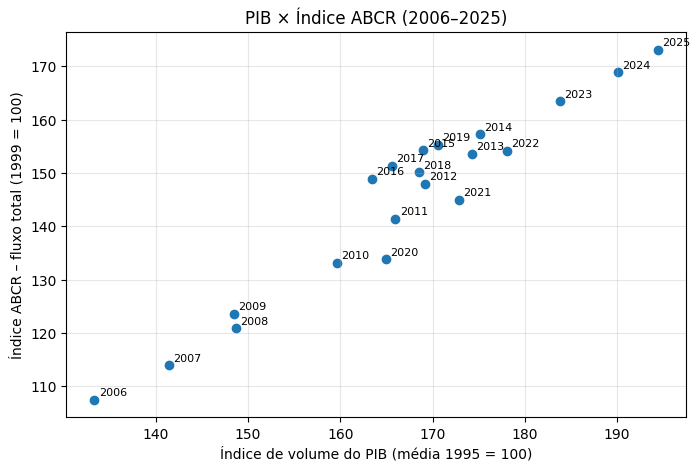

In [5]:
corr = base["PIB_indice"].corr(base["ABCR_indice"])
print(f"Correlação de Pearson: {corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(base["PIB_indice"], base["ABCR_indice"])
for _, r in base.iterrows():
    ax.annotate(int(r["Ano"]), (r["PIB_indice"], r["ABCR_indice"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Índice de volume do PIB (média 1995 = 100)")
ax.set_ylabel("Índice ABCR – fluxo total (1999 = 100)")
ax.set_title("PIB × Índice ABCR (2006–2025)")
ax.grid(alpha=0.3)
plt.show()

A correlação de Pearson entre os dois índices é de 0,964, o que indica uma associação linear positiva muito forte: nos anos de maior atividade econômica, o fluxo de veículos nas rodovias pedagiadas também tende a ser maior. O ponto de 2020 se afasta claramente da tendência, e o de 2021, em menor grau, também permanece abaixo dela. Em 2020, a retração do PIB foi moderada, mas o fluxo de veículos caiu de forma muito mais intensa por causa das restrições de circulação durante a pandemia, e em 2021 ainda não havia retornado ao patamar anterior. Os anos de 2015 e 2016 mostram um recuo conjunto dos dois indicadores, coerente com a recessão do período. Vale ressaltar que a correlação elevada indica associação, e não uma relação de causa e efeito, já que os dois indicadores podem responder a fatores comuns, como renda, emprego e produção industrial.

## Treinamento do modelo

Treinamento: foi ajustada uma regressão linear simples, com o índice do PIB como variável explicativa (`X`) e o Índice ABCR como variável resposta (`y`). A divisão respeita a ordem cronológica: os primeiros 16 anos (2006–2021) formam o conjunto de treino, e os quatro últimos (2022–2025), o de teste. Os registros não foram embaralhados, para que o modelo seja avaliado em anos posteriores aos usados no ajuste, como aconteceria em uma previsão real.

In [6]:
X = base[["PIB_indice"]]
y = base["ABCR_indice"]

X_treino, X_teste = X.iloc[:16], X.iloc[16:]
y_treino, y_teste = y.iloc[:16], y.iloc[16:]

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
print(f"ABCR = {modelo.intercept_:.3f} + {modelo.coef_[0]:.3f} × PIB")

ABCR = -56.784 + 1.215 × PIB


O coeficiente angular indica que, no período de treino, cada ponto adicional no índice do PIB está associado, em média, a um aumento de cerca de 1,21 ponto no Índice ABCR. O intercepto negativo não tem interpretação econômica direta, porque corresponde a um PIB igual a zero, muito fora da faixa observada. Ele serve apenas para posicionar a reta. Os anos de 2020 e 2021 fazem parte do treino e, por estarem abaixo da tendência, tendem a reduzir a inclinação estimada.

## Avaliação dos resultados

### Métricas e tabela de previsões

O desempenho do modelo foi medido no conjunto de teste (2022–2025) com três métricas. O **MAE** (erro absoluto médio) é a diferença média, em pontos do índice, entre os valores observados e os previstos. O **MSE** (erro quadrático médio) eleva os erros ao quadrado e, por isso, penaliza mais os desvios grandes. O **R²** (coeficiente de determinação) indica que proporção da variação do Índice ABCR no período de teste é explicada pelo modelo: 1 corresponde a um ajuste perfeito, e valores próximos de zero ou negativos indicam desempenho igual ou pior que simplesmente usar a média.

In [7]:
y_prev = modelo.predict(X_teste)

mae = mean_absolute_error(y_teste, y_prev)
mse = mean_squared_error(y_teste, y_prev)
r2 = r2_score(y_teste, y_prev)
print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")

resultado = pd.DataFrame({
    "Ano": base["Ano"].iloc[16:].values,
    "Observado": y_teste.values,
    "Previsto": y_prev.round(2),
})
resultado["Erro"] = (resultado["Observado"] - resultado["Previsto"]).round(2)
resultado

MAE: 4.948 | MSE: 25.939 | R²: 0.485


,Ano,Observado,Previsto,Erro
0,2022,154.12,159.46,-5.34
1,2023,163.49,166.47,-2.98
2,2024,168.88,174.10,-5.22
3,2025,173.12,179.38,-6.26


### Reta ajustada

O gráfico mostra a reta ajustada sobre os pontos de treino e de teste, o que permite visualizar a posição dos anos de teste em relação à tendência estimada.

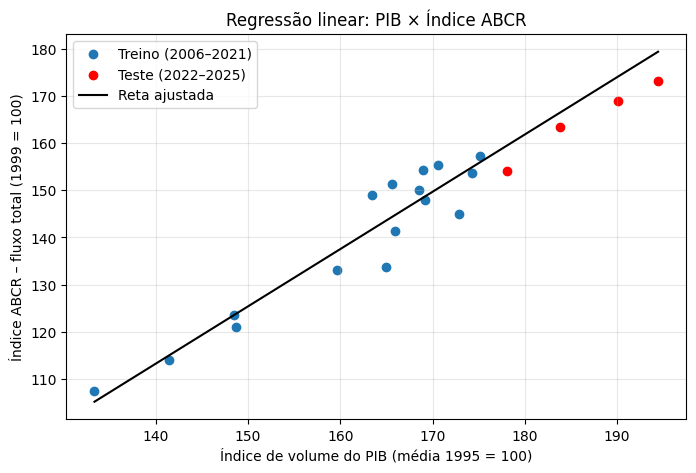

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_treino, y_treino, label="Treino (2006–2021)")
ax.scatter(X_teste, y_teste, color="red", label="Teste (2022–2025)")
x_linha = pd.DataFrame({"PIB_indice": sorted(base["PIB_indice"])})
ax.plot(x_linha, modelo.predict(x_linha), color="black", label="Reta ajustada")
ax.set_xlabel("Índice de volume do PIB (média 1995 = 100)")
ax.set_ylabel("Índice ABCR – fluxo total (1999 = 100)")
ax.set_title("Regressão linear: PIB × Índice ABCR")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

O modelo errou, em média, cerca de 4,9 pontos no Índice ABCR, o que equivale a aproximadamente 3% dos valores observados. Em termos absolutos, as estimativas ficaram próximas dos dados reais. No entanto, todos os erros são negativos: o modelo superestimou o fluxo de veículos nos quatro anos de teste, o que indica um viés sistemático, e não apenas uma variação aleatória.

O R² de 0,485 indica que o modelo explica pouco menos da metade da variação do Índice ABCR no período de teste. Esse valor é bem inferior ao que a correlação de 0,964 poderia sugerir, por três motivos:

Amostra de teste pequena: com apenas quatro pontos e pouca variação entre eles, o R² é muito sensível a qualquer desvio e se torna uma medida instável.
Extrapolação: o maior índice do PIB no treino é 175,14 (2014), e todos os anos de teste ficam acima desse valor. O modelo precisa estimar fora da faixa em que foi ajustado, onde não há garantia de que a relação linear se mantenha.
Possível mudança de patamar: depois da pandemia, o fluxo de veículos cresceu, mas manteve-se abaixo do nível que a relação histórica com o PIB indicaria. Essa diferença pode refletir mudanças de comportamento, como a expansão do trabalho remoto, mas os dados disponíveis não permitem confirmar essa hipótese.

Portanto, o PIB é um bom indicador da tendência geral do fluxo rodoviário, mas, sozinho, não captura choques e mudanças estruturais. A correlação elevada também não demonstra causalidade.

# **Conclusão**

Os resultados mostram uma associação linear positiva muito forte entre o PIB e o fluxo de veículos nas rodovias pedagiadas entre 2006 e 2025 (correlação de 0,964). No teste (2022–2025), o modelo teve erro médio de 4,95 pontos, cerca de 3% dos valores observados, e R² de 0,485, mas superestimou o fluxo em todos os anos. Esse viés se explica pela extrapolação para valores de PIB acima da faixa de treino, pela amostra de teste reduzida e por uma possível mudança de patamar após a pandemia.

Assim, o PIB acompanha bem a tendência de longo prazo do fluxo rodoviário, mas não é suficiente, sozinho, para previsões precisas. A correlação elevada indica associação, e não causalidade.